In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/revision_manual/df_cat.csv')
df.head(2)

,prompt
0,"I want to write an article about: ""Heavy relia..."
1,"I want to write an article about: ""The same mo..."


In [4]:
## gemini
df_gemini = pd.read_csv('../data/analisis/results_gemini_links.csv')
df_mistral = pd.read_csv('../data/results/results_mistral.csv')

## GPT

In [5]:
df_gpt1 = pd.read_csv('../data/results/results_gpt.csv')
df_gpt2 = pd.read_csv('../data/results/results_gpt_web_search_V2.csv')

In [6]:
df_gpt1.head(2)

,prompt,result,references,tokens
0,"I want to write an article about: ""Common fair...",Several studies demonstrate the mathematical i...,['https://jmlr.org/beta/papers/v24/22-1511.htm...,NaN
1,"I want to write an article about: ""Machine Lea...",Machine learning models can exhibit bias even ...,['https://www.forbes.com/sites/aparnadhinakara...,NaN


In [7]:
df_gpt2.head(2)

,prompt,result,references,tokens
0,"Explain the following statement: ""Common fairn...","The statement ""Common fairness definitions are...",['https://algorithmaudit.eu/knowledge-platform...,NaN
1,"Explain the following statement: ""Machine Lear...",Machine learning models can exhibit bias even ...,['https://www.forbes.com/sites/aparnadhinakara...,NaN


In [33]:
prompt = df['prompt'].iloc[9]
print(prompt)

Define "Extrinsic hallucinations". Include references.


In [27]:
df_gpt1[df_gpt1['prompt'] == prompt]

,prompt,result,references,tokens
2133,"Define ""Extrinsic hallucinations"". Include ref...",Extrinsic hallucinations refer to sensory perc...,[],NaN


In [28]:
df_gpt2[df_gpt2['prompt'] == prompt]

,prompt,result,references,tokens
1040,"Define ""Extrinsic hallucinations"". Include ref...","In the context of artificial intelligence, ""ex...",['https://www.emergentmind.com/topics/hallucin...,NaN


In [29]:
print(df_gpt2[df_gpt2['prompt'] == prompt]['references'].iloc[0])

['https://www.emergentmind.com/topics/hallucination-in-natural-language-generation?utm_source=openai', 'https://www.hopkinsguides.com/hopkins/view/Johns_Hopkins_Psychiatry_Guide/787023/all/Hallucinations?utm_source=openai', 'https://www.hopkinsguides.com/hopkins/view/Johns_Hopkins_Psychiatry_Guide/787023/2.0/Hallucinations?utm_source=openai', 'https://www.hopkinsguides.com/hopkins/view/Johns_Hopkins_Psychiatry_Guide/787023/2.2/Hallucinations?utm_source=openai', 'https://my.clevelandclinic.org/health/symptoms/23350-hallucinations?utm_source=openai', 'https://karger.com/psp/article/doi/10.1159/000548200/934526/Revising-the-Standard-Definition-of-Hallucination?utm_source=openai', 'https://www.emergentmind.com/topics/human-evaluation-of-hallucinations?utm_source=openai', 'https://www.pinecone.io/learn/ai-hallucinations/?utm_source=openai', 'https://omicstutorials.com/ai-hallucinations-why-it-matters/?utm_source=openai', 'https://openmd.com/define/hallucination?utm_source=openai', 'https://

In [30]:
print(df_gemini[df_gemini['prompt'] == prompt]['references_real'].iloc[0])

['https://www.pinecone.io/learn/ai-hallucinations/', 'https://rumn.medium.com/hallucinations-in-llm-explained-1f64929b7228', 'https://galileo.ai/blog/deep-dive-into-llm-hallucinations-across-generative-tasks', 'https://arxiv.org/html/2406.16338v1', 'https://medium.com/@rajacassian/understanding-intrinsic-and-extrinsic-hallucinations-in-ai-models-causes-biases-and-mitigation-d40e65f75fc4']


In [31]:
print(df_mistral[df_mistral['prompt'] == prompt]['references'].iloc[0])

['[1] American Psychiatric Association. (2013). Diagnostic and Statistical Manual of Mental Disorders (5th ed.). Arlington, VA: American Psychiatric Publishing.']


## Conteo de fuentes

In [35]:
df_gpt1 = pd.read_csv('../data/analisis/processed/gpt_url_checks.csv')
df_gpt1.head(2)

,prompt,result,references,tokens,urls_clean,url_checks
0,"I want to write an article about: ""Common fair...",Several studies demonstrate the mathematical i...,['https://jmlr.org/beta/papers/v24/22-1511.htm...,NaN,['https://jmlr.org/beta/papers/v24/22-1511.htm...,[{'url': 'https://jmlr.org/beta/papers/v24/22-...
1,"I want to write an article about: ""Machine Lea...",Machine learning models can exhibit bias even ...,['https://www.forbes.com/sites/aparnadhinakara...,NaN,['https://www.forbes.com/sites/aparnadhinakara...,[{'url': 'https://www.forbes.com/sites/aparnad...


In [37]:
df_gpt2 = pd.read_csv('../data/analisis/processed/gpt_web_search_url_checks.csv')
df_gpt2.head(2)

,prompt,result,references,tokens,urls_clean,url_checks
0,"Explain the following statement: ""Common fairn...","The statement ""Common fairness definitions are...",['https://algorithmaudit.eu/knowledge-platform...,NaN,['https://algorithmaudit.eu/knowledge-platform...,[{'url': 'https://algorithmaudit.eu/knowledge-...
1,"Explain the following statement: ""Machine Lear...",Machine learning models can exhibit bias even ...,['https://www.forbes.com/sites/aparnadhinakara...,NaN,['https://www.forbes.com/sites/aparnadhinakara...,[{'url': 'https://www.forbes.com/sites/aparnad...


In [38]:
df_gpt = pd.concat([df_gpt1, df_gpt2], ignore_index=True)

In [39]:
df_gemini = pd.read_csv('../data/analisis/processed/gemini_url_checks_progress.csv')
df_gemini.head(2)

,Unnamed: 0.1,Unnamed: 0,prompt,result,references,tokens,len_references,references_real,url_check
0,0,0,"I want to write an article about: ""Common fair...","The hypothesis that ""Common fairness definitio...","[""'https://vertexaisearch.cloud.google.com/gro...",NaN,16,['https://papers.neurips.cc/paper_files/paper/...,[{'url': 'https://papers.neurips.cc/paper_file...
1,1,1,"I want to write an article about: ""Machine Lea...",Here are references supporting the hypothesis ...,"[""'https://vertexaisearch.cloud.google.com/gro...",NaN,15,['https://medium.com/bcggamma/practice-ai-resp...,[{'url': 'https://medium.com/bcggamma/practice...


In [40]:
df_mistral = pd.read_csv('../data/analisis/processed/mistral_reference_checks.csv')
df_mistral.head(2)

,original_index,prompt,citation,title_extracted,venue_extracted,top_match,title_similarity,venue_similarity,venue_crossref,status
0,2,"I want to write an article about: ""Evaluation ...","Barocas, S., & Selbst, A. (2016). Big data's h...",Fairness in Machine Learning: A Survey,Communications of the ACM,{'title': 'Fairness in Machine Learning: A Sur...,1.0000,0.3913,ACM Computing Surveys,exists
1,2,"I want to write an article about: ""Evaluation ...","Chouldechova, A. (2017). The limits of fair ma...",Fairness in Algorithmic Decision Making: A Survey,Proceedings of the National Academy of Sciences,{'title': 'Fairness in Algorithmic Decision Ma...,0.8864,0.5102,Proceedings of the 7th ACM IKDD CoDS and 25th ...,exists


In [41]:
df_gemini.url_check.iloc[0]

"[{'url': 'https://papers.neurips.cc/paper_files/paper/2022/file/d3222559698f41247261b7a6c2bbaedc-Paper-Conference.pdf', 'exists': True, 'status_code': 200, 'final_url': 'https://papers.neurips.cc/paper_files/paper/2022/file/d3222559698f41247261b7a6c2bbaedc-Paper-Conference.pdf', 'error': None}, {'url': 'https://machinesgonewrong.com/fairness/', 'exists': True, 'status_code': 200, 'final_url': 'https://machinesgonewrong.com/fairness/', 'error': None}, {'url': 'https://arxiv.org/abs/2007.06024', 'exists': True, 'status_code': 200, 'final_url': 'https://arxiv.org/abs/2007.06024', 'error': None}, {'url': 'http://fitelson.org/primer.pdf', 'exists': True, 'status_code': 200, 'final_url': 'http://fitelson.org/primer.pdf', 'error': None}, {'url': 'https://www.researchgate.net/publication/325748511_Inherent_Trade-Offs_in_Algorithmic_Fairness', 'exists': True, 'status_code': 403, 'final_url': 'https://www.researchgate.net/publication/325748511_Inherent_Trade-Offs_in_Algorithmic_Fairness', 'erro

## Fuentes más frecuentes (URLs que existen)

In [45]:
import ast
from urllib.parse import urlparse
from collections import Counter
import matplotlib.pyplot as plt

def extraer_dominios_existentes(df, col_url_check):
    """
    De un df con una columna de listas de dicts {url, exists, ...},
    extrae los dominios de las URLs donde exists=True.
    Retorna un Counter con frecuencia de cada dominio.
    """
    dominios = []
    for celda in df[col_url_check].dropna():
        # La columna está guardada como string
        if isinstance(celda, str):
            try:
                checks = ast.literal_eval(celda)
            except Exception:
                continue
        else:
            checks = celda
        
        for entry in checks:
            if isinstance(entry, dict) and entry.get('exists') is True:
                url = entry.get('url', '')
                dominio = urlparse(url).netloc
                # Quitar prefijo www.
                dominio = dominio.removeprefix('www.')
                if dominio:
                    dominios.append(dominio)
    
    return Counter(dominios)


def graficar_top_fuentes(counter, titulo, top_n=20, color='steelblue'):
    top = counter.most_common(top_n)
    dominios = [d for d, _ in top]
    conteos = [c for _, c in top]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(dominios[::-1], conteos[::-1], color=color)
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_xlabel('Number of appearances')
    ax.set_title(titulo)
    ax.set_xlim(0, max(conteos) * 1.15)
    plt.tight_layout()
    plt.show()
    
    return top


### GPT

Total existing URLs GPT: 15345
Unique domains: 2607



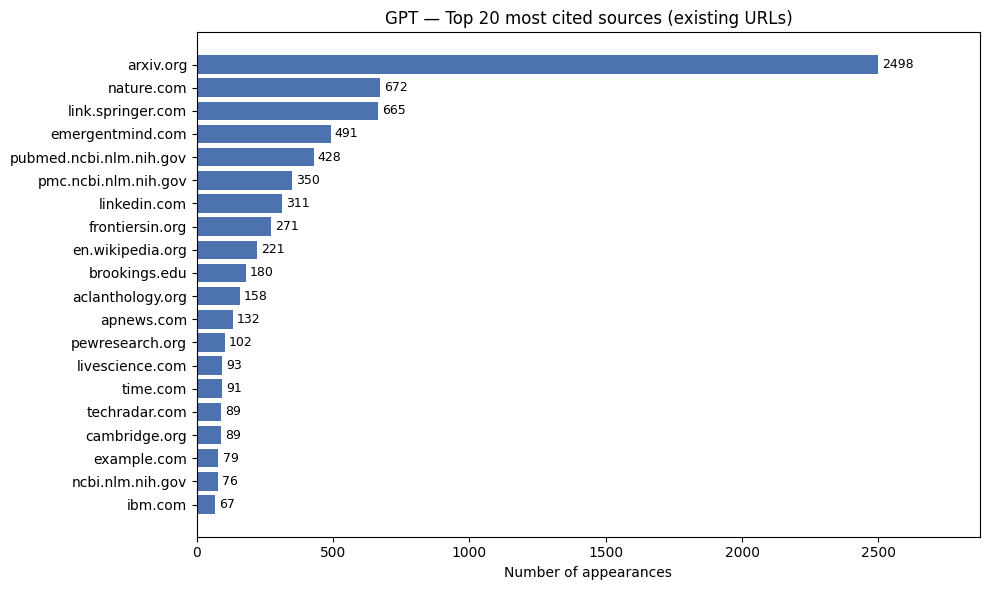

In [46]:
# df_gpt = concat de df_gpt1 + df_gpt2, columna se llama 'url_checks' (plural)
counter_gpt = extraer_dominios_existentes(df_gpt, 'url_checks')

print(f"Total existing URLs GPT: {sum(counter_gpt.values())}")
print(f"Unique domains: {len(counter_gpt)}\n")

top_gpt = graficar_top_fuentes(counter_gpt, 'GPT — Top 20 most cited sources (existing URLs)', color='#4C72B0')


### Gemini

Total existing URLs Gemini: 14755
Unique domains: 3534



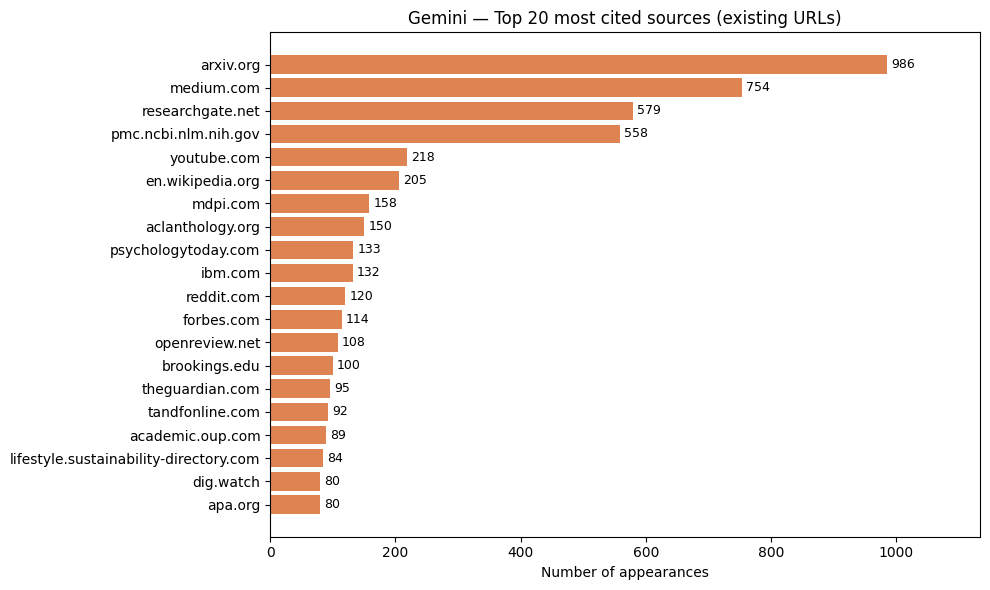

In [48]:
# df_gemini, columna se llama 'url_check' (singular)
counter_gemini = extraer_dominios_existentes(df_gemini, 'url_check')

print(f"Total existing URLs Gemini: {sum(counter_gemini.values())}")
print(f"Unique domains: {len(counter_gemini)}\n")

top_gemini = graficar_top_fuentes(counter_gemini, 'Gemini — Top 20 most cited sources (existing URLs)', color='#DD8452')


### Mistral

Total references with status='exists' (Mistral): 2810
  - with venue_crossref:  2720
  - fallback venue_extracted: 54
Unique venues: 592



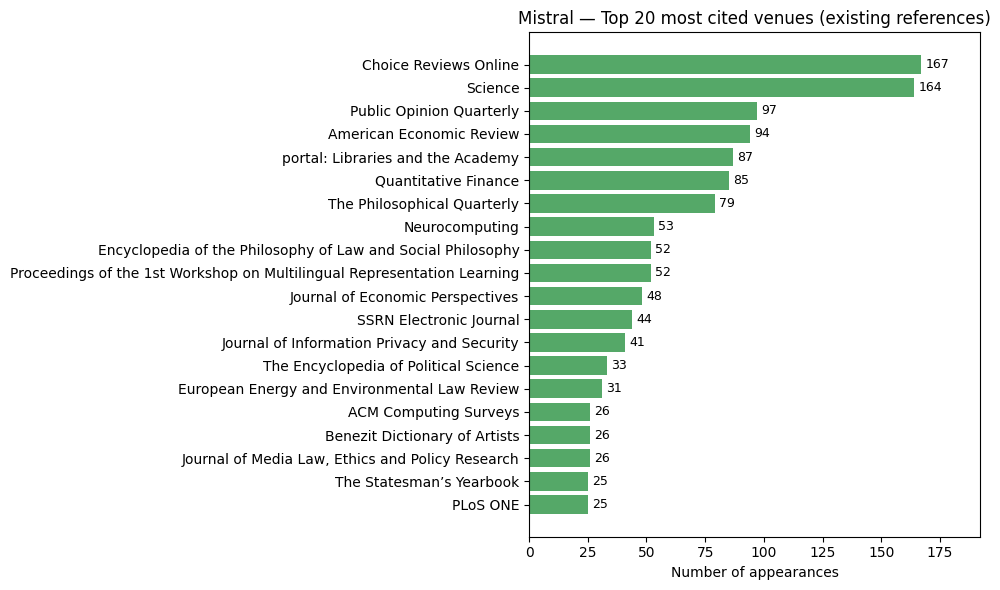

In [49]:
def extraer_venues_mistral(df, top_n=20, color='#55A868'):
    """
    Para Mistral, filtra status=='exists' y extrae el venue:
    usa venue_crossref si está disponible, si no venue_extracted como fallback.
    """
    df_exists = df[df['status'] == 'exists'].copy()

    def get_venue(row):
        venue = row.get('venue_crossref', '')
        if isinstance(venue, str) and venue.strip():
            return venue.strip()
        fallback = row.get('venue_extracted', '')
        if isinstance(fallback, str) and fallback.strip():
            return fallback.strip()
        return None

    venues = df_exists.apply(get_venue, axis=1).dropna()
    counter = Counter(venues)

    print(f"Total references with status='exists' (Mistral): {len(df_exists)}")
    print(f"  - with venue_crossref:  {df_exists['venue_crossref'].notna().sum() - (df_exists['venue_crossref'] == '').sum()}")
    print(f"  - fallback venue_extracted: {venues.shape[0] - df_exists['venue_crossref'].notna().sum()}")
    print(f"Unique venues: {len(counter)}\n")

    top = counter.most_common(top_n)
    venues_list = [v for v, _ in top]
    conteos = [c for _, c in top]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(venues_list[::-1], conteos[::-1], color=color)
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_xlabel('Number of appearances')
    ax.set_title('Mistral — Top 20 most cited venues (existing references)')
    ax.set_xlim(0, max(conteos) * 1.15)
    plt.tight_layout()
    plt.show()

    return top

top_mistral = extraer_venues_mistral(df_mistral)
